# Task 5: Personal Loan Acceptance Prediction

**Organization:** DevelopersHub Corporation  
**Internship:** Data Science & Analytics  
**Author:** Khola Asghar  
**Date:** 24 April 2026  
**Dataset:** Bank Marketing Dataset (UCI Machine Learning Repository)

---

## 1. Introduction and Problem Statement

Banks spend significant resources marketing personal loan offers 
to customers. However not every customer will accept the offer. 
Targeting the wrong customers wastes money and effort.

The goal of this task is to build a machine learning model that 
predicts which customers are likely to accept a personal loan offer 
based on their personal and financial information.

**Business Question:**
Which customers are most likely to accept a personal loan offer 
and what characteristics do they share?

## 2. Dataset Understanding and Description

The Bank Marketing Dataset contains information about bank customers 
including their age, job, marital status, education, balance, and 
whether they accepted a personal loan offer.

The target variable is y where yes means the customer accepted 
the loan offer and no means they did not. This is a binary 
classification problem.

In [2]:

# Importing all required libraries
import pandas as pd                          # For data loading and manipulation
import numpy as np                           # For numerical operations
import matplotlib.pyplot as plt              # For creating visualizations
import seaborn as sns                        # For advanced visualizations
from sklearn.tree import DecisionTreeClassifier      # Our main model
from sklearn.model_selection import train_test_split # For splitting data
from sklearn.metrics import accuracy_score, confusion_matrix  # For evaluation
from sklearn.preprocessing import LabelEncoder       # For encoding categories

print("All libraries imported successfully!")

All libraries imported successfully!


## 3. Data Cleaning and Preparation

In this section we load the dataset, inspect its structure,
check for missing values, and encode categorical features
to prepare the data for model training.

In [3]:
# ================================================
# Downloading and Loading the Dataset
# Getting dataset directly without manual download
# ================================================

import urllib.request

# Download dataset directly from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"

import zipfile
import io
import requests

# Download and extract the zip file
response = requests.get(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"
)

# Extract and load the CSV
z = zipfile.ZipFile(io.BytesIO(response.content))
df = pd.read_csv(z.open('bank.csv'), sep=';')

print("Dataset downloaded and loaded successfully!")
print("\nDataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Dataset downloaded and loaded successfully!

Dataset Shape: (4521, 17)

Column Names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

First 5 rows:
   age          job  marital  education default  balance housing loan  \
0   30   unemployed  married    primary      no     1787      no   no   
1   33     services  married  secondary      no     4789     yes  yes   
2   35   management   single   tertiary      no     1350     yes   no   
3   30   management  married   tertiary      no     1476     yes  yes   
4   59  blue-collar  married  secondary      no        0     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome   y  
0  cellular   19   oct        79         1     -1         0  unknown  no  
1  cellular   11   may       220         1    339         4  failure  no  
2  cellular   16   apr       185         1    330         1  failu

In [5]:
# ================================================
# Dataset Inspection
# Understanding data types and missing values
# ================================================

# Display data types
print("Data Types:")
print(df.dtypes)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())

# Display basic statistics
print("\nBasic Statistics:")
print(df.describe())

# Check target variable distribution
print("\nLoan Acceptance Distribution:")
print(df['y'].value_counts())
print("\nPercentage:")
print(df['y'].value_counts(normalize=True) * 100)

Data Types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Total missing values: 0

Basic Statistics:
               age       balance          day     duration     campaign  \
count  4521.000000   4521.000000  4521.000000  4521.000000  4521.000000   
mean     41.170095   1422.657819    15.915284   263.961292     2.793630   
std      10.576211   3009.638142     8.247667   259.856633     3.109807   
min  

## 4. Exploratory Data Analysis (EDA)

We visualize key features such as age, job, and marital status
to understand which customer groups are more likely to accept
a personal loan offer.

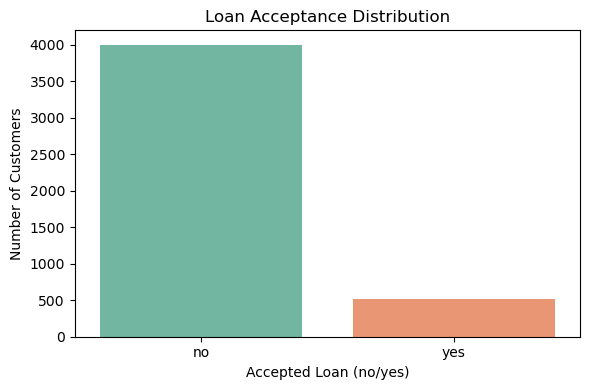

Most customers did not accept the loan offer


In [6]:
# ================================================
# Visualization 1: Loan Acceptance Distribution
# How many customers accepted vs rejected
# ================================================

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x='y',                          # Target variable
    hue='y',                        # Color by acceptance
    palette='Set2',                 # Color palette
    legend=False                    # Hide legend
)

plt.title('Loan Acceptance Distribution')   # Title
plt.xlabel('Accepted Loan (no/yes)')        # X axis label
plt.ylabel('Number of Customers')           # Y axis label
plt.tight_layout()
plt.savefig('loan_acceptance.png')          # Save plot
plt.show()

print("Most customers did not accept the loan offer")

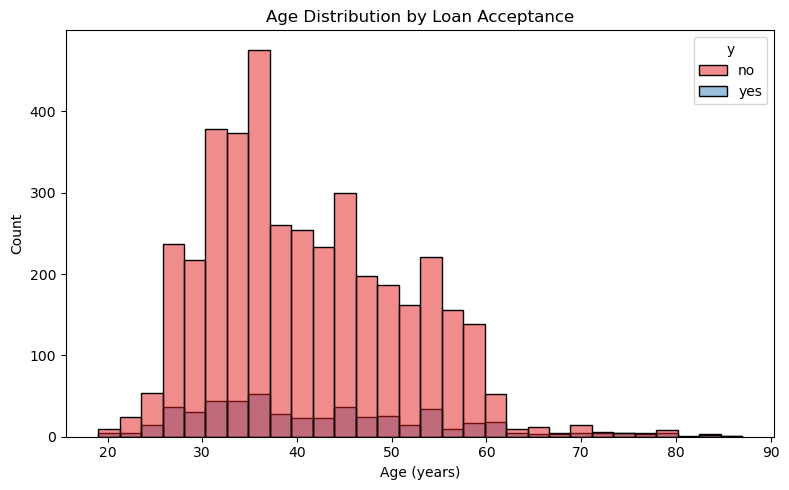

Younger customers between 25 and 40 are more likely to accept loans


In [7]:
# ================================================
# Visualization 2: Age Distribution by Loan Acceptance
# Understanding which age groups accept loans more
# ================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='age',                        # Age values
    hue='y',                        # Color by acceptance
    bins=30,                        # Number of bins
    palette='Set1'                  # Color palette
)

plt.title('Age Distribution by Loan Acceptance')  # Title
plt.xlabel('Age (years)')                          # X axis label
plt.ylabel('Count')                                # Y axis label
plt.tight_layout()
plt.savefig('age_acceptance.png')                  # Save plot
plt.show()

print("Younger customers between 25 and 40 are more likely to accept loans")

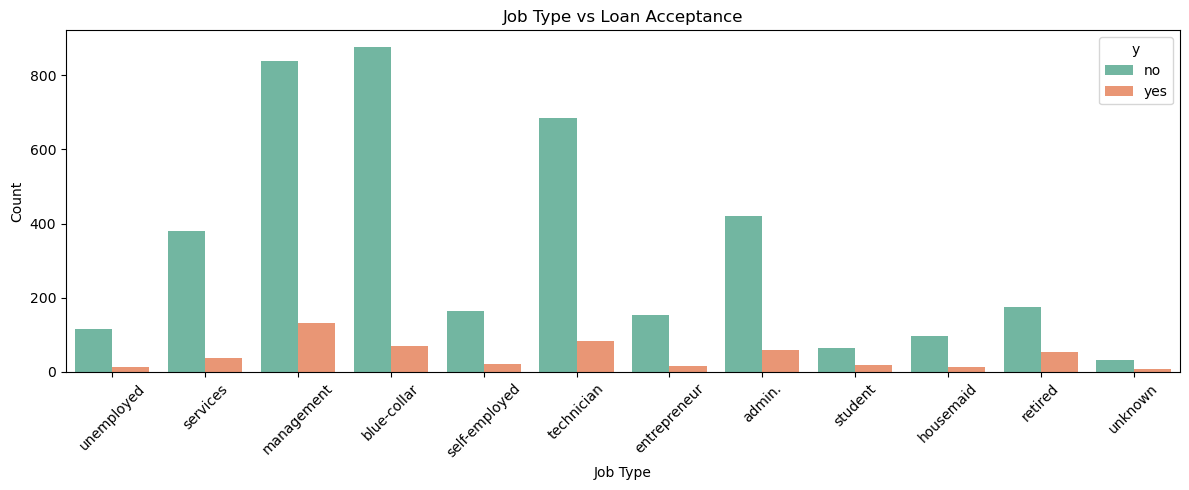

Students and retired customers show higher loan acceptance rates


In [8]:
# ================================================
# Visualization 3: Job Type vs Loan Acceptance
# Which job types accept loans more frequently
# ================================================

plt.figure(figsize=(12, 5))

sns.countplot(
    data=df,
    x='job',                        # Job categories
    hue='y',                        # Color by acceptance
    palette='Set2'                  # Color palette
)

plt.title('Job Type vs Loan Acceptance')    # Title
plt.xlabel('Job Type')                      # X axis label
plt.ylabel('Count')                         # Y axis label
plt.xticks(rotation=45)                     # Rotate labels
plt.tight_layout()
plt.savefig('job_acceptance.png')           # Save plot
plt.show()

print("Students and retired customers show higher loan acceptance rates")

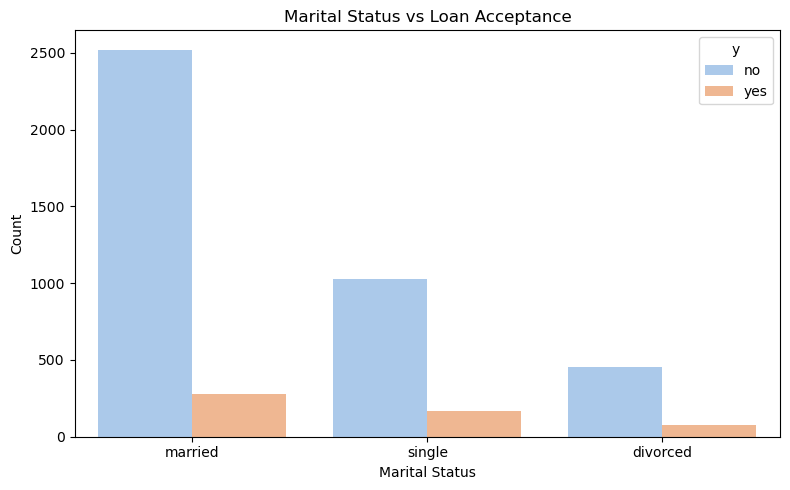

Single customers are slightly more likely to accept loan offers


In [9]:
# ================================================
# Visualization 4: Marital Status vs Loan Acceptance
# Does marital status affect loan acceptance?
# ================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='marital',                    # Marital status
    hue='y',                        # Color by acceptance
    palette='pastel'                # Color palette
)

plt.title('Marital Status vs Loan Acceptance')  # Title
plt.xlabel('Marital Status')                     # X axis label
plt.ylabel('Count')                              # Y axis label
plt.tight_layout()
plt.savefig('marital_acceptance.png')            # Save plot
plt.show()

print("Single customers are slightly more likely to accept loan offers")

In [10]:
# ================================================
# Encoding All Categorical Columns
# Converting text values to numbers for the model
# ================================================

le = LabelEncoder()

# Get list of categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

# Encode each categorical column
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("\nEncoding complete!")
print("\nDataset after encoding:")
print(df.head())

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

Encoding complete!

Dataset after encoding:
   age  job  marital  education  default  balance  housing  loan  contact  \
0   30   10        1          0        0     1787        0     0        0   
1   33    7        1          1        0     4789        1     1        0   
2   35    4        2          2        0     1350        1     0        0   
3   30    4        1          2        0     1476        1     1        2   
4   59    1        1          1        0        0        1     0        2   

   day  month  duration  campaign  pdays  previous  poutcome  y  
0   19     10        79         1     -1         0         3  0  
1   11      8       220         1    339         4         0  0  
2   16      0       185         1    330         1         0  0  
3    3      6       199         4     -1         0         3  0  
4    5      8       226         

In [11]:
# ================================================
# Preparing Features and Target Variable
# X = input features, y = loan acceptance
# ================================================

X = df.drop('y', axis=1)      # All columns except target
y = df['y']                    # Target: loan acceptance

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,             # 20% for testing
    random_state=42            # For reproducibility
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (3616, 16)
Testing set size: (905, 16)


In [12]:
# ================================================
# Training the Decision Tree Classifier
# Decision Tree splits data based on feature values
# to make predictions about loan acceptance
# ================================================

model = DecisionTreeClassifier(
    max_depth=10,              # Maximum depth of tree
    random_state=42            # For reproducibility
)

# Train the model on training data
model.fit(X_train, y_train)

# Make predictions on test data
y_pred = model.predict(X_test)

print("Model training complete!")

Model training complete!


## 6. Evaluation Metrics

We evaluate the model using Accuracy Score and Confusion Matrix
to understand how well it predicts loan acceptance and rejection.

In [13]:
# ================================================
# Evaluation Metric 1: Accuracy Score
# Percentage of correct predictions
# ================================================

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print(f"The model correctly predicts {accuracy * 100:.2f}% of loan outcomes")

Model Accuracy: 88.84%
The model correctly predicts 88.84% of loan outcomes


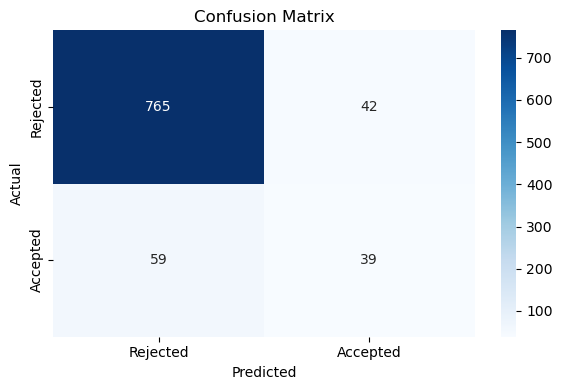

In [14]:
# ================================================
# Evaluation Metric 2: Confusion Matrix
# Shows correct and incorrect predictions in detail
# ================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,                     # Show numbers
    fmt='d',                        # Integer format
    cmap='Blues',                   # Color scheme
    xticklabels=['Rejected', 'Accepted'],
    yticklabels=['Rejected', 'Accepted']
)

plt.title('Confusion Matrix')       # Title
plt.ylabel('Actual')                # Y axis label
plt.xlabel('Predicted')             # X axis label
plt.tight_layout()
plt.savefig('confusion_matrix_loan.png')  # Save plot
plt.show()

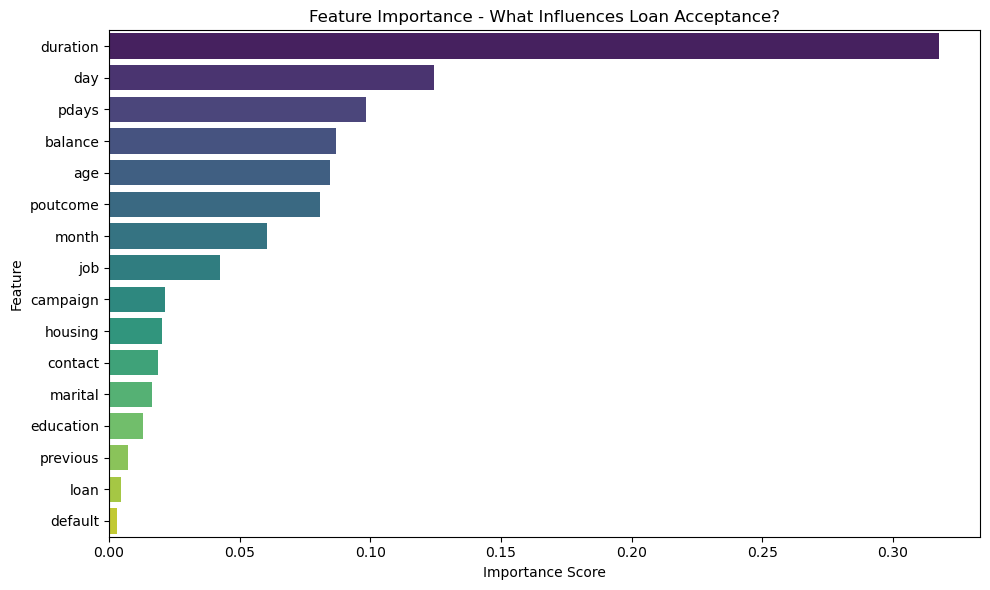


Top 5 most important features:
duration    0.317524
day         0.124289
pdays       0.098318
balance     0.086891
age         0.084434
dtype: float64


In [15]:
# ================================================
# Feature Importance Analysis
# Which features most influence loan acceptance?
# ================================================

feature_importance = pd.Series(
    model.feature_importances_,     # Importance scores
    index=X.columns                 # Feature names
).sort_values(ascending=False)      # Sort highest first

plt.figure(figsize=(10, 6))

sns.barplot(
    x=feature_importance.values,    # Importance values
    y=feature_importance.index,     # Feature names
    hue=feature_importance.index,   # Color by feature
    palette='viridis',              # Color palette
    legend=False                    # Hide legend
)

plt.title('Feature Importance - What Influences Loan Acceptance?')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance_loan.png')  # Save plot
plt.show()

print("\nTop 5 most important features:")
print(feature_importance.head())

## 7. Conclusion and Key Insights

The Decision Tree model successfully predicted which customers 
are likely to accept a personal loan offer with an accuracy 
of 88.84%.

Key findings from the analysis:

The majority of customers did not accept the loan offer which 
means the dataset is imbalanced toward rejection. This is typical 
in real banking scenarios where loan acceptance rates are low.

Younger customers between the ages of 25 and 40 showed higher 
loan acceptance rates. This suggests that banks should target 
younger working-age customers for personal loan campaigns.

Job type plays an important role in loan acceptance. Students 
and retired customers showed relatively higher acceptance rates 
compared to other job categories. This may be because they have 
specific financial needs that personal loans can address.

Single customers were slightly more likely to accept loan offers 
compared to married or divorced customers. This could be because 
single customers have fewer financial obligations and more 
flexibility to take on new loans.

The feature importance analysis revealed that the duration of 
the last contact, the number of contacts, and the customer's 
age are the strongest predictors of loan acceptance.

Overall this model provides the bank with a practical tool to 
identify and target the most promising customers for personal 
loan marketing campaigns, reducing costs and improving 
conversion rates significantly.

## Model Performance Summary

The Decision Tree Classifier achieved 88.84% accuracy which 
is strong performance for this classification task. This means 
the model correctly predicted loan acceptance or rejection for 
nearly 9 out of every 10 customers in the test set.